# SVM - Метод опорных векторов

Используется и для классификации и для регрессии. По простому - рисует разделяющую линию для данных.

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [71]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [73]:
data = iris[['sepal_length', 'petal_length', 'species']]
data.head()

,sepal_length,petal_length,species
0,5.1,1.4,setosa
1,4.9,1.4,setosa
2,4.7,1.3,setosa
3,4.6,1.5,setosa
4,5.0,1.4,setosa


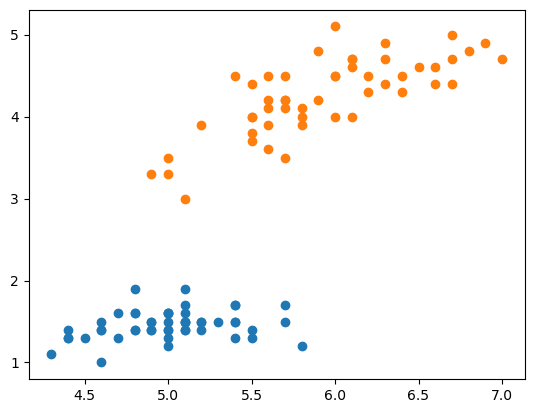

In [75]:
data_df = data[(data['species'] == 'setosa') | (data['species'] == 'versicolor')]
data_df_setosa = data_df[data_df['species'] == 'setosa']
data_df_versicolor = data_df[data_df['species'] == 'versicolor']

plt.scatter(data_df_setosa['sepal_length'], data_df_setosa['petal_length'])
plt.scatter(data_df_versicolor['sepal_length'], data_df_versicolor['petal_length'])
plt.show()

In [77]:
from sklearn.svm import SVC

X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

model = SVC(kernel='linear', C=10000)
model.fit(X, y)

print(model.support_vectors_)

[[4.8 1.9]
 [5.1 1.9]
 [5.1 3. ]]


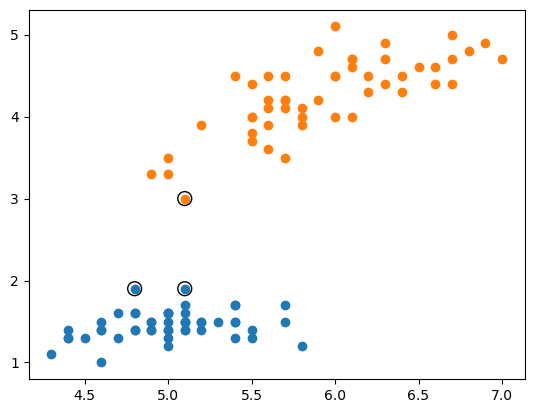

In [79]:
plt.scatter(data_df_setosa['sepal_length'], data_df_setosa['petal_length'])
plt.scatter(data_df_versicolor['sepal_length'], data_df_versicolor['petal_length'])
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, facecolor='none', edgecolor='black')
plt.show()

In [81]:
x1_p = np.linspace(min(data_df['sepal_length']), max(data_df['sepal_length']), 100)
x2_p = np.linspace(min(data_df['petal_length']), max(data_df['petal_length']), 100)

X1_p, X2_p = np.meshgrid(x1_p, x2_p)
X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=['sepal_length', 'petal_length'])
X_p.head()

,sepal_length,petal_length
0,4.300000,1.0
1,4.327273,1.0
2,4.354545,1.0
3,4.381818,1.0
4,4.409091,1.0


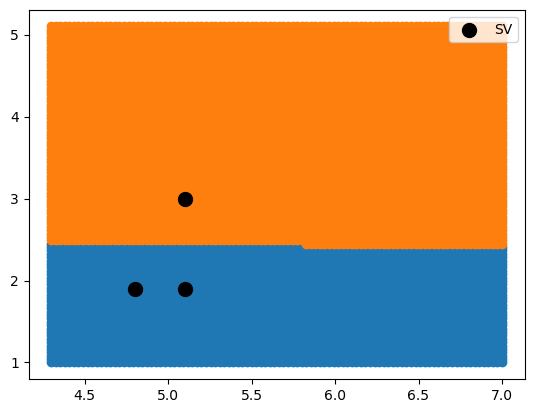

In [83]:
y_p = model.predict(X_p)
X_p['species'] = y_p

X_p_setosa = X_p[X_p['species'] == 'setosa']
X_p_versicolor = X_p[X_p['species'] == 'versicolor']

plt.scatter(X_p_setosa['sepal_length'], X_p_setosa['petal_length'])
plt.scatter(X_p_versicolor['sepal_length'], X_p_versicolor['petal_length'])
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, color='black', label='SV')
plt.legend()
plt.show()

In [111]:
# Домашнее задание
to_del = np.random.randint(1, 149, 10)
new_iris = iris.drop(to_del)
print(new_iris.shape, iris.shape)

(140, 5) (150, 5)


In [113]:
data = new_iris[['sepal_length', 'petal_length', 'species']]
data_df = data[(data['species'] == 'setosa') | (data['species'] == 'versicolor')]
data_df_setosa = data_df[data_df['species'] == 'setosa']
data_df_versicolor = data_df[data_df['species'] == 'versicolor']

X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

model = SVC(kernel='linear', C=10000)
model.fit(X, y)

print(model.support_vectors_)

[[4.8 1.9]
 [5.1 1.9]
 [5.1 3. ]]


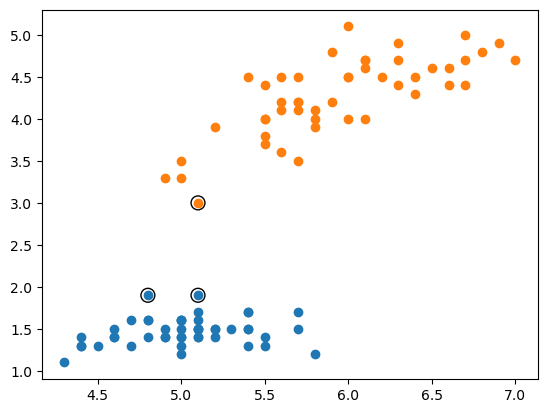

In [115]:
plt.scatter(data_df_setosa['sepal_length'], data_df_setosa['petal_length'])
plt.scatter(data_df_versicolor['sepal_length'], data_df_versicolor['petal_length'])
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, facecolor='none', edgecolor='black')
plt.show()

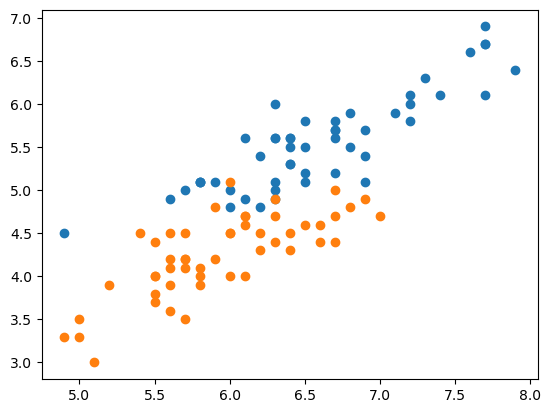

In [121]:
data = iris[['sepal_length', 'petal_length', 'species']]
data_df = data[(data['species'] == 'virginica') | (data['species'] == 'versicolor')]
data_df_virginica = data_df[data_df['species'] == 'virginica']
data_df_versicolor = data_df[data_df['species'] == 'versicolor']

plt.scatter(data_df_virginica['sepal_length'], data_df_virginica['petal_length'])
plt.scatter(data_df_versicolor['sepal_length'], data_df_versicolor['petal_length'])
plt.show()

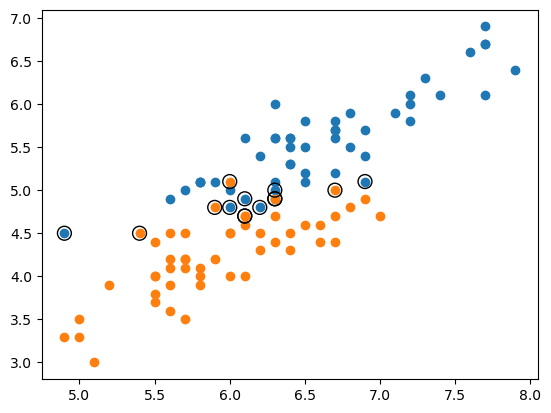

In [123]:
X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

model = SVC(kernel='linear', C=10000)
model.fit(X, y)

plt.scatter(data_df_virginica['sepal_length'], data_df_virginica['petal_length'])
plt.scatter(data_df_versicolor['sepal_length'], data_df_versicolor['petal_length'])
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100, facecolor='none', edgecolor='black')
plt.show()

В случае перекрытия данных, идеальной границы не существует. У модели существует гиперпараметр, который определяет "размытие" отступа - С. чем меньше С, тем более размытый отступ.

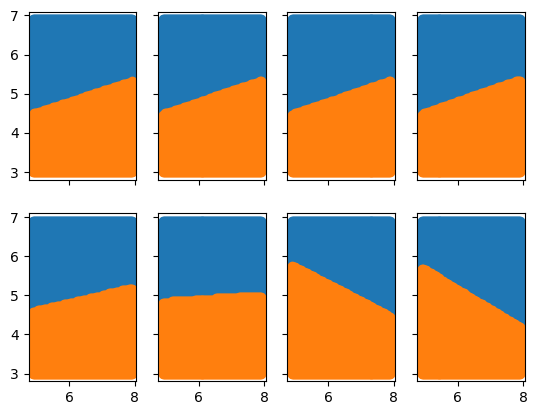

In [132]:
c_value = [[10000, 1000, 100, 10],
           [1, 0.1, 0.01, 0.001]]

fig, ax = plt.subplots(2, 4, sharex='col', sharey='row')

for i in range(2):
    for j in range(4):
        model = SVC(kernel='linear', C=c_value[i][j])
        model.fit(X, y)

        x1_p = np.linspace(min(data_df['sepal_length']), max(data_df['sepal_length']), 100)
        x2_p = np.linspace(min(data_df['petal_length']), max(data_df['petal_length']), 100)

        X1_p, X2_p = np.meshgrid(x1_p, x2_p)
        X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=['sepal_length', 'petal_length'])
        
        y_p = model.predict(X_p)
        X_p['species'] = y_p

        X_p_virginica = X_p[X_p['species'] == 'virginica']
        X_p_versicolor = X_p[X_p['species'] == 'versicolor']

        ax[i][j].scatter(X_p_virginica['sepal_length'], X_p_virginica['petal_length'])
        ax[i][j].scatter(X_p_versicolor['sepal_length'], X_p_versicolor['petal_length'])
        

plt.show()

Достоинства:
- Компактна
- После обучения получаем предсказания очень быстро
- На работу методв влияет только несколько опорных векторов

Недостатки:
- При большом количестве сэмплов будут большие вычислительные затраты
- Поиск С приводит к большим вычислительным затратам
- У результатов отсутствует вероятностная интерпритация

# Деревья решений и random forest

Деревья решений и рандомный лес - непараметрические модели. Случайный лес - пример ансамблевого метода (агрегируем результаты нескольких моделей). В реализации дерева решений вопросы ведут к разделению данных по осям. 

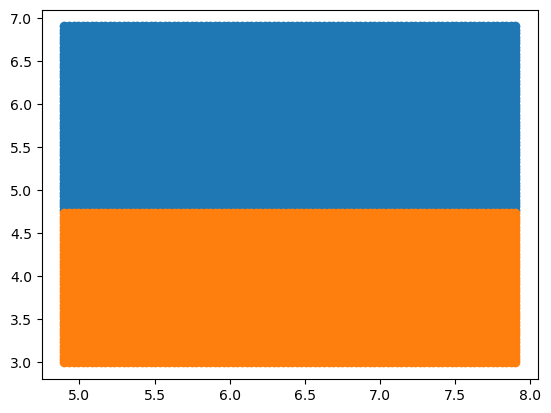

In [141]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=1)
model.fit(X, y)

x1_p = np.linspace(min(data_df['sepal_length']), max(data_df['sepal_length']), 100)
x2_p = np.linspace(min(data_df['petal_length']), max(data_df['petal_length']), 100)

X1_p, X2_p = np.meshgrid(x1_p, x2_p)
X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=['sepal_length', 'petal_length'])
        
y_p = model.predict(X_p)
X_p['species'] = y_p

X_p_virginica = X_p[X_p['species'] == 'virginica']
X_p_versicolor = X_p[X_p['species'] == 'versicolor']

plt.scatter(X_p_virginica['sepal_length'], X_p_virginica['petal_length'])
plt.scatter(X_p_versicolor['sepal_length'], X_p_versicolor['petal_length'])

plt.show()

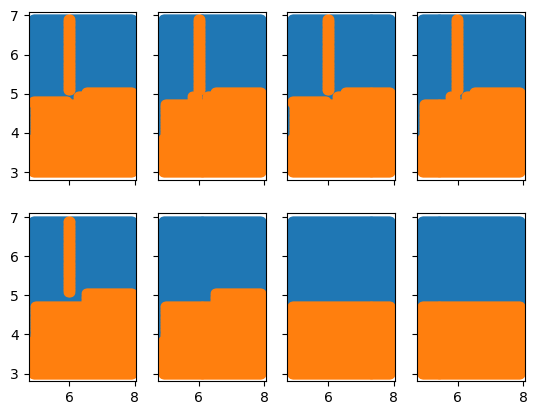

In [147]:
c_value = [[10000, 1000, 100, 10],
           [4, 3, 2, 1]]

fig, ax = plt.subplots(2, 4, sharex='col', sharey='row')

for i in range(2):
    for j in range(4):
        model = DecisionTreeClassifier(max_depth=c_value[i][j])
        model.fit(X, y)

        x1_p = np.linspace(min(data_df['sepal_length']), max(data_df['sepal_length']), 100)
        x2_p = np.linspace(min(data_df['petal_length']), max(data_df['petal_length']), 100)

        X1_p, X2_p = np.meshgrid(x1_p, x2_p)
        X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=['sepal_length', 'petal_length'])
        
        y_p = model.predict(X_p)
        X_p['species'] = y_p

        X_p_virginica = X_p[X_p['species'] == 'virginica']
        X_p_versicolor = X_p[X_p['species'] == 'versicolor']

        ax[i][j].scatter(X_p_virginica['sepal_length'], X_p_virginica['petal_length'])
        ax[i][j].scatter(X_p_versicolor['sepal_length'], X_p_versicolor['petal_length'])
        

plt.show()